In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.data.load import load_rideshare_data
from src.data.clean import drop_missing_price, drop_unused_columns
from src.data.save import save_csv
from src.features.encode import encode_features
from src.features.split import split_data
from src.features.scale import scale_data

In [3]:
df = load_rideshare_data("../data/raw/rideshare_kaggle.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 693071 entries, 0 to 693070
Data columns (total 57 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           693071 non-null  object 
 1   timestamp                    693071 non-null  float64
 2   hour                         693071 non-null  int64  
 3   day                          693071 non-null  int64  
 4   month                        693071 non-null  int64  
 5   datetime                     693071 non-null  object 
 6   timezone                     693071 non-null  object 
 7   source                       693071 non-null  object 
 8   destination                  693071 non-null  object 
 9   cab_type                     693071 non-null  object 
 10  product_id                   693071 non-null  object 
 11  name                         693071 non-null  object 
 12  price                        637976 non-null  float64
 13 

In [4]:
df.head()

,id,timestamp,hour,day,month,datetime,timezone,source,destination,cab_type,...,precipIntensityMax,uvIndexTime,temperatureMin,temperatureMinTime,temperatureMax,temperatureMaxTime,apparentTemperatureMin,apparentTemperatureMinTime,apparentTemperatureMax,apparentTemperatureMaxTime
0,424553bb-7174-41ea-aeb4-fe06d4f4b9d7,1.544953e+09,9,16,12,2018-12-16 09:30:07,America/New_York,Haymarket Square,North Station,Lyft,...,0.1276,1544979600,39.89,1545012000,43.68,1544968800,33.73,1545012000,38.07,1544958000
1,4bd23055-6827-41c6-b23b-3c491f24e74d,1.543284e+09,2,27,11,2018-11-27 02:00:23,America/New_York,Haymarket Square,North Station,Lyft,...,0.1300,1543251600,40.49,1543233600,47.30,1543251600,36.20,1543291200,43.92,1543251600
2,981a3613-77af-4620-a42a-0c0866077d1e,1.543367e+09,1,28,11,2018-11-28 01:00:22,America/New_York,Haymarket Square,North Station,Lyft,...,0.1064,1543338000,35.36,1543377600,47.55,1543320000,31.04,1543377600,44.12,1543320000
3,c2d88af2-d278-4bfd-a8d0-29ca77cc5512,1.543554e+09,4,30,11,2018-11-30 04:53:02,America/New_York,Haymarket Square,North Station,Lyft,...,0.0000,1543507200,34.67,1543550400,45.03,1543510800,30.30,1543550400,38.53,1543510800
4,e0126e1f-8ca9-4f2e-82b3-50505a09db9a,1.543463e+09,3,29,11,2018-11-29 03:49:20,America/New_York,Haymarket Square,North Station,Lyft,...,0.0001,1543420800,33.10,1543402800,42.18,1543420800,29.11,1543392000,35.75,1543420800


In [5]:
df.describe()

,timestamp,hour,day,month,price,distance,surge_multiplier,latitude,longitude,temperature,...,precipIntensityMax,uvIndexTime,temperatureMin,temperatureMinTime,temperatureMax,temperatureMaxTime,apparentTemperatureMin,apparentTemperatureMinTime,apparentTemperatureMax,apparentTemperatureMaxTime
count,6.930710e+05,693071.000000,693071.000000,693071.000000,637976.000000,693071.000000,693071.000000,693071.000000,693071.000000,693071.000000,...,693071.000000,6.930710e+05,693071.000000,6.930710e+05,693071.000000,6.930710e+05,693071.000000,6.930710e+05,693071.000000,6.930710e+05
mean,1.544046e+09,11.619137,17.794365,11.586684,16.545125,2.189430,1.013870,42.338172,-71.066151,39.584388,...,0.037374,1.544044e+09,33.457774,1.544042e+09,45.261313,1.544047e+09,29.731002,1.544048e+09,41.997343,1.544048e+09
std,6.891925e+05,6.948114,9.982286,0.492429,9.324359,1.138937,0.091641,0.047840,0.020302,6.726084,...,0.055214,6.912028e+05,6.467224,6.901954e+05,5.645046,6.901353e+05,7.110494,6.871862e+05,6.936841,6.910777e+05
min,1.543204e+09,0.000000,1.000000,11.000000,2.500000,0.020000,1.000000,42.214800,-71.105400,18.910000,...,0.000000,1.543162e+09,15.630000,1.543122e+09,33.510000,1.543154e+09,11.810000,1.543136e+09,28.950000,1.543187e+09
25%,1.543444e+09,6.000000,13.000000,11.000000,9.000000,1.280000,1.000000,42.350300,-71.081000,36.450000,...,0.000000,1.543421e+09,30.170000,1.543399e+09,42.570000,1.543439e+09,27.760000,1.543399e+09,36.570000,1.543439e+09
50%,1.543737e+09,12.000000,17.000000,12.000000,13.500000,2.160000,1.000000,42.351900,-71.063100,40.490000,...,0.000400,1.543770e+09,34.240000,1.543727e+09,44.680000,1.543788e+09,30.130000,1.543745e+09,40.950000,1.543788e+09
75%,1.544828e+09,18.000000,28.000000,12.000000,22.500000,2.920000,1.000000,42.364700,-71.054200,43.580000,...,0.091600,1.544807e+09,38.880000,1.544789e+09,46.910000,1.544814e+09,35.710000,1.544789e+09,44.120000,1.544818e+09
max,1.545161e+09,23.000000,30.000000,12.000000,97.500000,7.860000,3.000000,42.366100,-71.033000,57.220000,...,0.145900,1.545152e+09,43.100000,1.545192e+09,57.870000,1.545109e+09,40.050000,1.545134e+09,57.200000,1.545109e+09


In [6]:
print(f"{df.shape[0]} แถว และ {df.shape[1]} คอลัมน์")

693071 แถว และ 57 คอลัมน์


# Data Cleaning

In [7]:
null_counts = df.isnull().sum()
print(null_counts[null_counts > 0])

price    55095
dtype: int64


In [8]:
df[['price', 'distance', 'surge_multiplier']].describe()

,price,distance,surge_multiplier
count,637976.000000,693071.000000,693071.000000
mean,16.545125,2.189430,1.013870
std,9.324359,1.138937,0.091641
min,2.500000,0.020000,1.000000
25%,9.000000,1.280000,1.000000
50%,13.500000,2.160000,1.000000
75%,22.500000,2.920000,1.000000
max,97.500000,7.860000,3.000000


### drop ทิ้งเพราะ price คือ target

In [9]:
df = drop_missing_price(df)

print(f"จำนวนแถวคงเหลือ: {len(df)}")

จำนวนแถวคงเหลือ: 637976


# Feature Selection

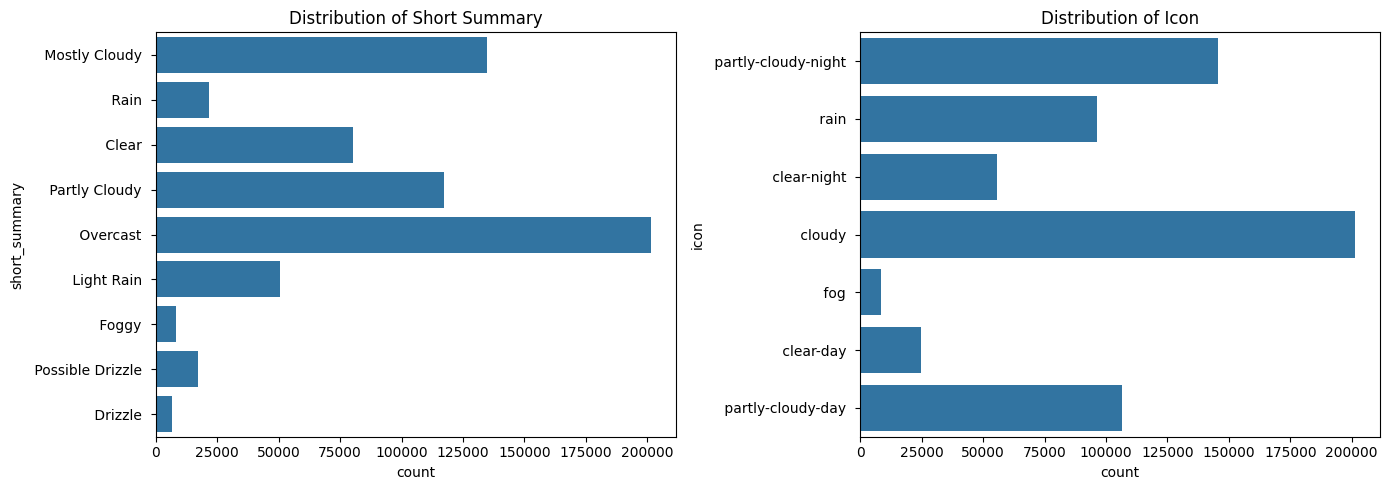

Correlation between Short Summary and Icon:
icon               clear-day   clear-night   cloudy   fog   \
short_summary                                                
Clear                   24679         55577        0     0   
Drizzle                     0             0        0     0   
Foggy                       0             0        0  8292   
Light Rain                  0             0        0     0   
Mostly Cloudy               0             0        0     0   
Overcast                    0             0   201429     0   
Partly Cloudy               0             0        0     0   
Possible Drizzle            0             0        0     0   
Rain                        0             0        0     0   

icon               partly-cloudy-day   partly-cloudy-night   rain   
short_summary                                                       
Clear                               0                     0      0  
Drizzle                             0                     0   6725

In [10]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.countplot(y='short_summary', data=df)
plt.title('Distribution of Short Summary')

plt.subplot(1, 2, 2)
sns.countplot(y='icon', data=df)
plt.title('Distribution of Icon')

plt.tight_layout()
plt.show()

print("Correlation between Short Summary and Icon:")
print(pd.crosstab(df['short_summary'], df['icon']))

### มีแค่ Lyft ที่มีตัวคูณ Uber น่าจะซ่อนไว้


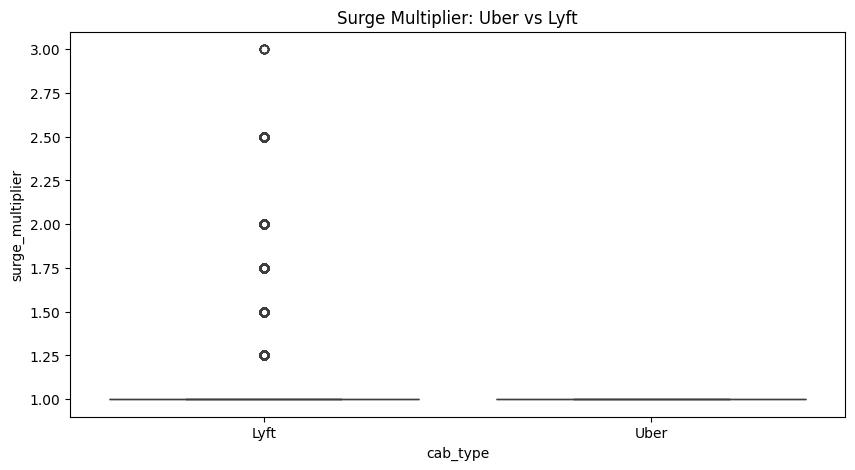

Surge Multiplier counts for each brand:
cab_type  surge_multiplier
Lyft      1.00                286433
          1.25                 11085
          1.50                  5065
          1.75                  2420
          2.00                  2239
          2.50                   154
          3.00                    12
Uber      1.00                330568
Name: count, dtype: int64


In [11]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='cab_type', y='surge_multiplier', data=df)
plt.title('Surge Multiplier: Uber vs Lyft')
plt.show()

# ดูจำนวนตัวเลขเพื่อความชัวร์
print("Surge Multiplier counts for each brand:")
print(df.groupby('cab_type')['surge_multiplier'].value_counts())

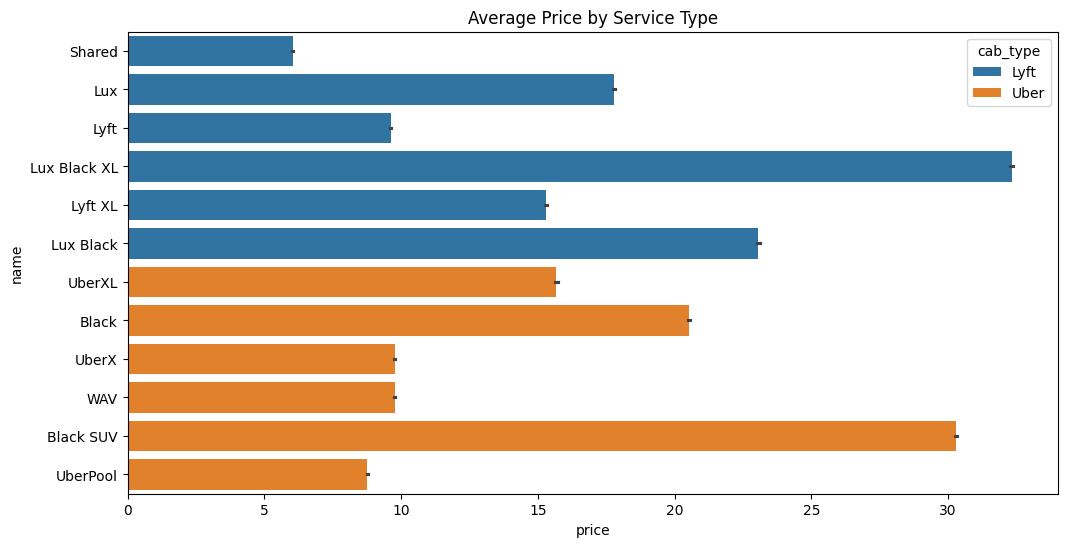

In [12]:
plt.figure(figsize=(12, 6))
sns.barplot(x='price', y='name', data=df, hue='cab_type')
plt.title('Average Price by Service Type')
plt.show()

### drop ส่วนที่ซ้ำออก หรือ 1-to-1 เช่น timestamp มี hour day month อยู่แล้ว กับพวก temperatureHighTime ซึ่งเวลาคำนวนจริงไม่ได้เอามาคิด

In [13]:
df_cleaned = drop_unused_columns(df)

print(f"จำนวนคอลัมน์คงเหลือ: {df_cleaned.shape[1]}")
df_cleaned.head()

จำนวนคอลัมน์คงเหลือ: 37


,hour,day,month,source,destination,cab_type,name,price,distance,surge_multiplier,...,windBearing,cloudCover,uvIndex,ozone,moonPhase,precipIntensityMax,temperatureMin,temperatureMax,apparentTemperatureMin,apparentTemperatureMax
0,9,16,12,Haymarket Square,North Station,Lyft,Shared,5.0,0.44,1.0,...,57,0.72,0,303.8,0.30,0.1276,39.89,43.68,33.73,38.07
1,2,27,11,Haymarket Square,North Station,Lyft,Lux,11.0,0.44,1.0,...,90,1.00,0,291.1,0.64,0.1300,40.49,47.30,36.20,43.92
2,1,28,11,Haymarket Square,North Station,Lyft,Lyft,7.0,0.44,1.0,...,240,0.03,0,315.7,0.68,0.1064,35.36,47.55,31.04,44.12
3,4,30,11,Haymarket Square,North Station,Lyft,Lux Black XL,26.0,0.44,1.0,...,310,0.00,0,291.1,0.75,0.0000,34.67,45.03,30.30,38.53
4,3,29,11,Haymarket Square,North Station,Lyft,Lyft XL,9.0,0.44,1.0,...,303,0.44,0,347.7,0.72,0.0001,33.10,42.18,29.11,35.75


# Outlier Analysis
ไม่ลบเพราะแพงจริงๆ ไม่ใช่ค่ามั่ว

In [14]:
Q1 = df_cleaned['price'].quantile(0.25)
Q3 = df_cleaned['price'].quantile(0.75)
IQR = Q3 - Q1

upper_limit = Q3 + 1.5 * IQR
lower_limit = Q1 - 1.5 * IQR

outliers_check = df_cleaned[df_cleaned['price'] > upper_limit]

print(outliers_check[['name', 'price', 'distance', 'surge_multiplier', 'short_summary']].head(10))

              name  price  distance  surge_multiplier    short_summary
706      Lux Black   52.5      3.25              2.00   Partly Cloudy 
707   Lux Black XL   67.5      3.25              2.00   Partly Cloudy 
769   Lux Black XL   45.5      4.76              1.00   Partly Cloudy 
1094  Lux Black XL   45.5      4.31              1.00      Light Rain 
1318  Lux Black XL   45.5      5.33              1.00        Overcast 
1321  Lux Black XL   45.5      4.50              1.00   Partly Cloudy 
1333  Lux Black XL   45.5      0.46              1.75           Foggy 
1762  Lux Black XL   47.5      5.32              1.00      Light Rain 
1936  Lux Black XL   45.5      4.35              1.00   Partly Cloudy 
2043  Lux Black XL   52.5      2.81              1.50   Partly Cloudy 


# Categorical Encoding

In [15]:
df_encoded = encode_features(df_cleaned)

print("การแปลงข้อมูลเสร็จสมบูรณ์!")
print(f"ขนาดข้อมูลใหม่: {df_encoded.shape}")
df_encoded.head()

การแปลงข้อมูลเสร็จสมบูรณ์!
ขนาดข้อมูลใหม่: (637976, 44)


,hour,day,month,source,destination,name,price,distance,surge_multiplier,latitude,...,apparentTemperatureMax,cab_type_Uber,short_summary_ Drizzle,short_summary_ Foggy,short_summary_ Light Rain,short_summary_ Mostly Cloudy,short_summary_ Overcast,short_summary_ Partly Cloudy,short_summary_ Possible Drizzle,short_summary_ Rain
0,9,16,12,5,7,7,5.0,0.44,1.0,42.2148,...,38.07,False,False,False,False,True,False,False,False,False
1,2,27,11,5,7,2,11.0,0.44,1.0,42.2148,...,43.92,False,False,False,False,False,False,False,False,True
2,1,28,11,5,7,5,7.0,0.44,1.0,42.2148,...,44.12,False,False,False,False,False,False,False,False,False
3,4,30,11,5,7,4,26.0,0.44,1.0,42.2148,...,38.53,False,False,False,False,False,False,False,False,False
4,3,29,11,5,7,6,9.0,0.44,1.0,42.2148,...,35.75,False,False,False,False,False,False,True,False,False


In [16]:
df_encoded.dtypes

hour                                  int64
day                                   int64
month                                 int64
source                                int64
destination                           int64
name                                  int64
price                               float64
distance                            float64
surge_multiplier                    float64
latitude                            float64
longitude                           float64
temperature                         float64
apparentTemperature                 float64
precipIntensity                     float64
precipProbability                   float64
humidity                            float64
windSpeed                           float64
windGust                            float64
visibility                          float64
temperatureHigh                     float64
temperatureLow                      float64
apparentTemperatureHigh             float64
apparentTemperatureLow          

# Export Processed Data

In [17]:
output_cleaned = "../data/processed/rideshare_cleaned.csv"
output_encoded = "../data/processed/rideshare_encoded.csv"
save_csv(df_cleaned, output_cleaned)
save_csv(df_encoded, output_encoded)

print(f"บันทึกไฟล์เรียบร้อย: {output_cleaned}")
print(f"ขนาดข้อมูลที่บันทึก: {df_cleaned.shape[0]} แถว x {df_cleaned.shape[1]} คอลัมน์")
print(f"บันทึกไฟล์เรียบร้อย: {output_encoded}")
print(f"ขนาดข้อมูลที่บันทึก: {df_encoded.shape[0]} แถว x {df_encoded.shape[1]} คอลัมน์")

บันทึกไฟล์เรียบร้อย: ../data/processed/rideshare_cleaned.csv
ขนาดข้อมูลที่บันทึก: 637976 แถว x 37 คอลัมน์
บันทึกไฟล์เรียบร้อย: ../data/processed/rideshare_encoded.csv
ขนาดข้อมูลที่บันทึก: 637976 แถว x 44 คอลัมน์


# Train/Test Split , Feature Scaling

In [18]:
X_train, X_test, y_train, y_test = split_data(df_encoded)
X_train_scaled, X_test_scaled, scaler = scale_data(X_train, X_test)

print("Feature Scaling สำเร็จ!")
print(f"ค่าเฉลี่ยของ X_train_scaled (ควรเกือบเป็น 0): {X_train_scaled.mean():.2f}")

Feature Scaling สำเร็จ!
ค่าเฉลี่ยของ X_train_scaled (ควรเกือบเป็น 0): 0.00
